# ML-02 — Research Question and Provisional Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*

Freestyle direction: Growth / Recovery / Momentum Prediction


i want a challenge and to find if i am ready for real work or not 

## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

Predicting page trends can help the content owner make decisions. For example, if a page is falling, it tells them that they might need to make changes to help improve its trend.

However, if a prediction is made incorrectly, it can cause a rising page to fall. Furthermore, failing to find a falling page will make the owner lose opportunities and waste resources and time on the wrong page

## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\Programing\flyrank-ml-internship-assignments\data\raw\content_refresh_anonymized.csv")

In [2]:
df.head()


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [3]:
print(df.shape)

(30000, 44)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  str    
 1   client_id               30000 non-null  str    
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  str    
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  str    
 7   main_intent             27626 non-null  str    
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   str    
 11  model_used              24267 non-null  str    
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null  int64  
 

In [5]:
# droping indentifiers
df = df.drop(['content_id',"client_id"],axis=1)

In [6]:
# Filter out the "dead" pages that have less than 100 impressions in the last 90 days
visible_pages = df[df['impressions_90d'] >= 100]

# Now, use visible_pages for your analysis instead of the raw df!
print(f"Original rows: {len(df)}")
print(f"Trustworthy rows: {len(visible_pages)}")

Original rows: 30000
Trustworthy rows: 22006


In [7]:
# Quick check of missingness
print(visible_pages.isna().sum().sort_values(ascending=False))

provider_used             15824
word_count                 6555
char_count                 6555
word_count_tier            6555
char_count_tier            6555
model_used                 5311
competition_level           679
cpc                         565
competition                 565
search_volume               565
main_intent                 494
trend_pct                   248
scroll_rate                  27
content_type                  0
impressions_90d               0
clicks_90d                    0
pageviews_90d                 0
sessions_90d                  0
days_with_impressions         0
days_with_sessions            0
impressions_last_30d          0
clicks_last_30d               0
users_90d                     0
engaged_sessions_90d          0
ai_sessions_90d               0
scroll_events_90d             0
sessions_prev_30d             0
clicks_prev_30d               0
impressions_prev_30d          0
sessions_last_30d             0
days_since_last_update        0
age_tier

In [8]:
valid_trends = ['down', 'stable', 'up']
filtered_data = visible_pages[visible_pages['trend_direction'].isin(valid_trends)]
filtered_data.info()

<class 'pandas.DataFrame'>
Index: 21758 entries, 0 to 29999
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   search_volume           21201 non-null  float64
 1   competition             21201 non-null  float64
 2   competition_level       21087 non-null  str    
 3   cpc                     21201 non-null  float64
 4   content_type            21758 non-null  str    
 5   main_intent             21272 non-null  str    
 6   word_count              15227 non-null  float64
 7   char_count              15227 non-null  float64
 8   provider_used           6143 non-null   str    
 9   model_used              16448 non-null  str    
 10  impressions_90d         21758 non-null  int64  
 11  clicks_90d              21758 non-null  int64  
 12  pageviews_90d           21758 non-null  int64  
 13  sessions_90d            21758 non-null  int64  
 14  users_90d               21758 non-null  int64  
 15  e

In [29]:
print(filtered_data.describe())

       search_volume   competition           cpc    word_count     char_count  \
count   21201.000000  21201.000000  21201.000000  15227.000000   15227.000000   
mean      165.923306      0.142665      0.462913   3342.846194   22000.727655   
std      1638.996186      0.279494      1.863728   1471.026607    9992.620085   
min         0.000000      0.000000      0.000000    675.000000    4629.000000   
25%         0.000000      0.000000      0.000000   2574.000000   16726.500000   
50%        10.000000      0.000000      0.000000   2923.000000   19286.000000   
75%        20.000000      0.120000      0.000000   3777.500000   24757.500000   
max     74000.000000      1.000000     46.630000   9546.000000  109458.000000   

       impressions_90d    clicks_90d  pageviews_90d  sessions_90d  \
count     21758.000000  21758.000000   21758.000000  21758.000000   
mean       7144.551383     22.107501      67.100423     49.471321   
std       19417.331715     87.404551     175.510164    123.4015

In [11]:
filtered_data['trend_direction'].value_counts(normalize=True)

trend_direction
down      0.604467
stable    0.240463
up        0.155069
Name: proportion, dtype: float64

In [12]:
summary = filtered_data.groupby("trend_direction")[["impressions_90d", "clicks_90d", "ctr", "avg_position", "engagement_rate"]].mean()
summary

,impressions_90d,clicks_90d,ctr,avg_position,engagement_rate
trend_direction,,,,,
down,6074.179745,16.481296,0.229380,15.991423,2.653187
stable,10494.318998,38.875191,0.315182,16.328479,3.002636
up,6122.483699,18.037344,0.277599,23.616953,3.207792


C:\Users\abram\AppData\Local\Temp\ipykernel_1508\2957234604.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filtered_data, x='trend_direction', y='ctr', order=valid_trends, ax=axes[0], palette='Reds')
C:\Users\abram\AppData\Local\Temp\ipykernel_1508\2957234604.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filtered_data, x='trend_direction', y='engagement_rate', order=valid_trends, ax=axes[1], palette='Blues')


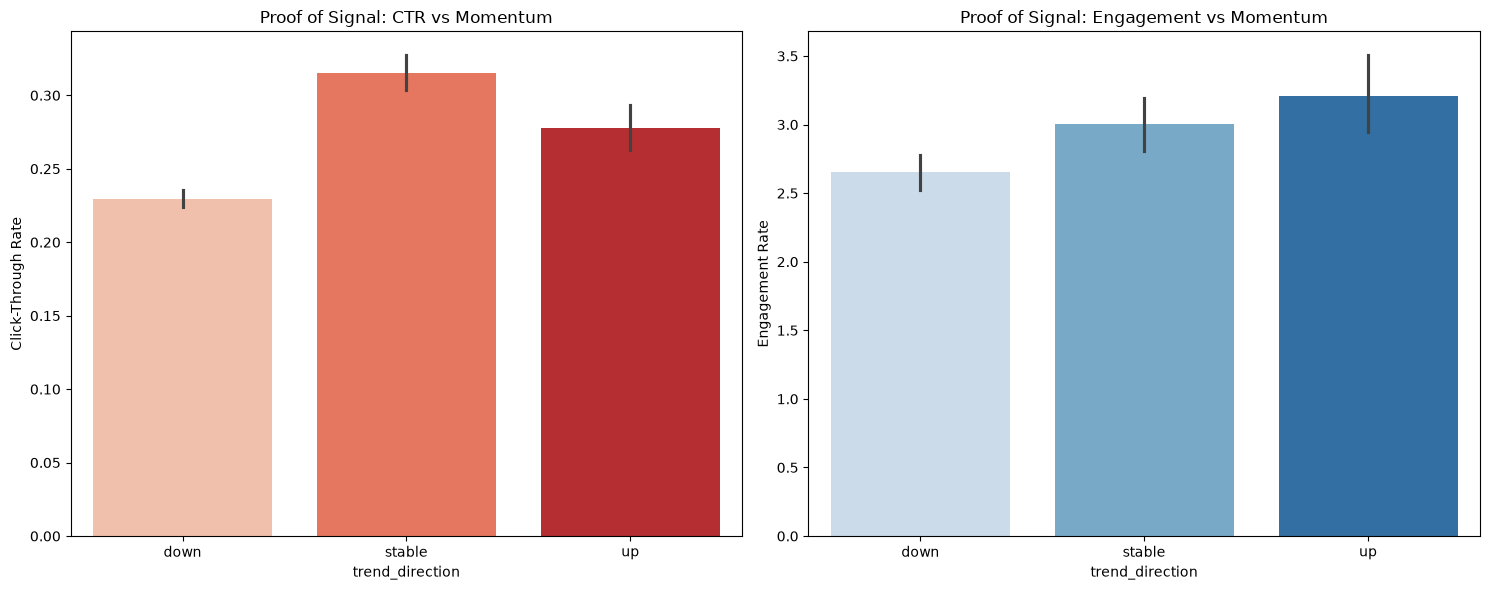

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))


sns.barplot(data=filtered_data, x='trend_direction', y='ctr', order=valid_trends, ax=axes[0], palette='Reds')
axes[0].set_title('Proof of Signal: CTR vs Momentum')
axes[0].set_ylabel('Click-Through Rate')

# Plot 2: Engagement Rate
sns.barplot(data=filtered_data, x='trend_direction', y='engagement_rate', order=valid_trends, ax=axes[1], palette='Blues')
axes[1].set_title('Proof of Signal: Engagement vs Momentum')
axes[1].set_ylabel('Engagement Rate')

plt.tight_layout()
plt.show()

In [32]:
print(filtered_data.groupby(['trend_direction','content_type'])['ctr'].median())

trend_direction  content_type      
down             comparison article    0.000
                 feedly article        0.190
                 keyword article       0.130
stable           comparison article    0.000
                 feedly article        0.345
                 keyword article       0.200
up               comparison article    0.000
                 feedly article        0.270
                 keyword article       0.150
Name: ctr, dtype: float64


In [ ]:
filtered_data['content_type'].value_counts(normalize='index')


content_type
keyword article       0.967322
comparison article    0.016821
feedly article        0.015856
Name: proportion, dtype: float64

                       mean  median
trend_direction                    
down             237.937348   221.0
stable           300.750191   309.0
up               294.628927   306.0


<Axes: xlabel='trend_direction', ylabel='content_age_days'>

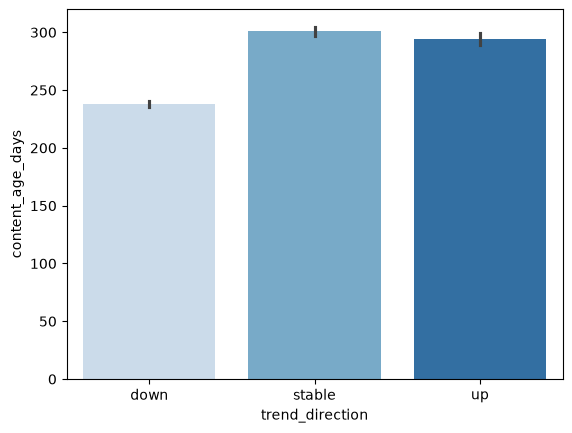

In [41]:
print(filtered_data.groupby(['trend_direction'])['content_age_days'].agg(['mean','median']))
sns.barplot(data=filtered_data,x='trend_direction',y='content_age_days',hue='trend_direction',order=valid_trends, palette='Blues')


In [34]:
age_proof = pd.crosstab(
    index=filtered_data['age_tier'], 
    columns=filtered_data['trend_direction'], 
    normalize='index' 
)

print(age_proof.mul(100).round(1))

trend_direction  down  stable    up
age_tier                           
181-365          60.8    25.1  14.1
31-90            68.3    14.2  17.5
365+             42.9    34.5  22.6
91-180           70.8    16.9  12.3


In [ ]:
print(filtered_data.groupby(['trend_direction'])['days_since_last_update'].agg(['mean','median']))

print("the more days it take's to update a page the more likely to fail ")

                      mean  median
trend_direction                   
down             51.998251    22.0
stable           52.148700    22.0
up               45.916123    22.0


In [31]:
print(filtered_data.groupby(['trend_direction'])['search_volume'].agg(['mean','median']))

                       mean  median
trend_direction                    
down             130.729370    10.0
stable           209.511765    10.0
up               236.101591    10.0


In [43]:
n = len(filtered_data)
counts = filtered_data['trend_direction'].value_counts()
pct_down = 100 * counts.get('down', 0) / n

print(f"Rows after filters: {n}")
print(f"Pages with trend 'down': {counts.get('down',0)} ({pct_down:.1f}%)\n")

print("Median impressions_90d by trend:")
print(filtered_data.groupby('trend_direction')['impressions_90d'].median().to_string(), "\n")

print("Median days_since_last_update by trend:")
print(filtered_data.groupby('trend_direction')['days_since_last_update'].mean().to_string())

Rows after filters: 21758
Pages with trend 'down': 13152 (60.4%)

Median impressions_90d by trend:
trend_direction
down      1620.5
stable    2642.0
up        1073.0 

Median days_since_last_update by trend:
trend_direction
down      51.998251
stable    52.148700
up        45.916123


## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

In [ ]:
there is a rel

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.